# Testing/Looking at Weather Station Data

In [27]:
#importing file correctly
import pandas as pd
import matplotlib.pyplot as plt

path = "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/VIC/weather_obs/HD01D_Data_086361_9999999910708904.txt"

df = pd.read_csv(
    path,
    sep=",",      # it’s comma-separated
    header=0      # first line is the header
)

/jobfs/158691942.gadi-pbs/ipykernel_456424/2153027437.py:6: DtypeWarning: Columns (12,15,17,20,23,25,28,31,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [30]:
#check columns
df.columns.tolist()

['hd',
 'Station Number',
 ' Year Month Day Hour Minutes in YYYY',
 'MM',
 'DD',
 'HH24',
 'MI format in Local time',
 ' Year Month Day Hour Minutes in YYYY.1',
 'MM.1',
 'DD.1',
 'HH24.1',
 'MI format in Local standard time',
 'Total precipitation in last 5 minutes in mm where observations count >= 2',
 'Quality Total precipitation in last 5 minutes',
 'Count of total precipitation observations in last 5 minutes',
 'Air Temperature in degrees Celsius',
 'Quality of air temperature',
 'Highest air temperature in last 5 minutes in degrees Celsius where observations count >= 2',
 'Quality of highest air temperature in last 5 minutes',
 'Count of highest air temperature observations in last 5 minutes',
 'Lowest air temperature in last 5 minutes in degrees Celsius where observations count >= 2',
 'Quality of lowest air temperature in last 5 minutes',
 'Count of lowest air temperature observations in last 5 minutes',
 'Dew point temperature in degrees Celsius',
 'Quality of dew point temper

In [35]:
year_col   = [c for c in df.columns if "year" in c.lower() and "local" not in c.lower()][0]
month_col  = [c for c in df.columns if c == "MM"][0]
day_col    = [c for c in df.columns if c == "DD"][0]
hour_col   = [c for c in df.columns if c == "HH24"][0]
minute_col = [c for c in df.columns if "mi format in local time" in c.lower()][0]

year_col, month_col, day_col, hour_col, minute_col

(' Year Month Day Hour Minutes in YYYY',
 'MM',
 'DD',
 'HH24',
 'MI format in Local time')

In [36]:
#building timestamp
df["timestamp"] = pd.to_datetime(
    df[year_col].astype(str).str.zfill(4) + "-" +
    df[month_col].astype(str).str.zfill(2) + "-" +
    df[day_col].astype(str).str.zfill(2) + " " +
    df[hour_col].astype(str).str.zfill(2) + ":" +
    df[minute_col].astype(str).str.zfill(2),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [39]:
#identify temperature column
[col for col in df.columns if "air temperature" in col.lower()]
temp_col = "Air Temperature in degrees Celsius"

In [41]:
#filtering last 2 months of data
cutoff = df["timestamp"].max() - pd.DateOffset(months=2)
df_recent = df[df["timestamp"] >= cutoff]

#checking rows
len(df_recent)

17557

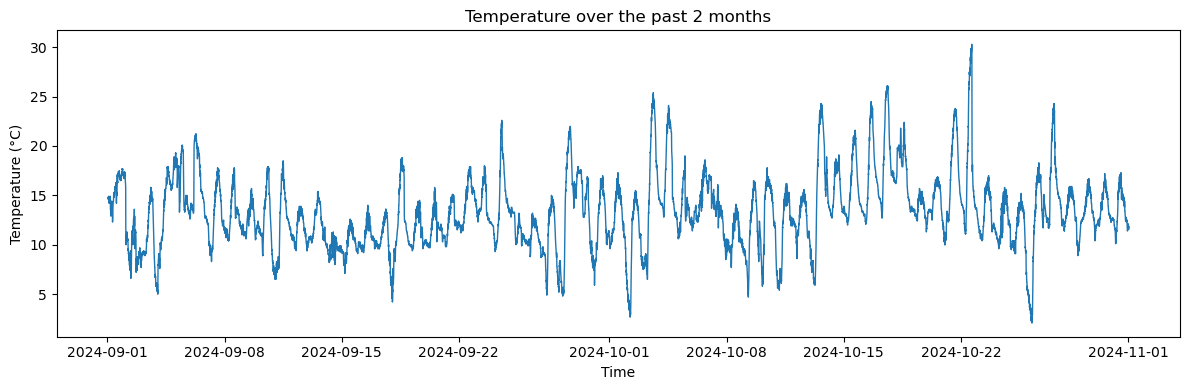

In [42]:
#ploting temperature vs time
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(
    df_recent["timestamp"],
    df_recent[temp_col],
    linewidth=1
)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature over the past 2 months")
plt.tight_layout()
plt.show()

# Using metadata to find location and name of this weather station

In [43]:
import os

folder = os.path.dirname(path)
[x for x in os.listdir(folder) if "StnDet" in x]

['HD01D_StnDet_9999999910708904.txt', 'HD01D_StnDet_9999999910708835.txt']

In [59]:
#loading correct StnDet file
stn_path = os.path.join(folder, "HD01D_StnDet_9999999910708904.txt")

stn = pd.read_csv(stn_path, header=None)

In [60]:
stn.head(10)

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,st,85099,85,POUND CREEK,04/2007,,-38.6297,145.8107,,VIC,...,94886,2010,2024,99,99,*,0,*,*,#
1,st,85151,85,YARRAM AIRPORT,10/2007,,-38.5647,146.7479,GPS,VIC,...,95890,2010,2024,99,99,*,0,*,*,#
2,st,85279,85,BAIRNSDALE AIRPORT,07/1942,,-37.8818,147.5669,GPS,VIC,...,94912,2008,2024,99,99,*,0,*,*,#
3,st,85280,85,MORWELL (LATROBE VALLEY AIRPORT),01/1984,,-38.2094,146.4746,GPS,VIC,...,94891,2005,2024,99,99,1,0,*,*,#
4,st,85291,85,MOUNT BAW BAW,09/1991,,-37.8384,146.2747,GPS,VIC,...,95901,2011,2024,99,99,*,0,*,*,#
5,st,85296,85,MOUNT MOORNAPA,12/1993,,-37.7481,147.1428,GPS,VIC,...,95913,2010,2024,99,99,*,0,*,*,#
6,st,85301,85,CORNER INLET (YANAKIE),01/2013,,-38.8051,146.1936,GPS,VIC,...,94911,2013,2024,99,99,*,0,*,*,#
7,st,85313,85,NILMA NORTH (WARRAGUL),01/2014,,-38.1321,145.9865,GPS,VIC,...,99806,2014,2024,99,99,*,0,*,*,#
8,st,85314,85,EAST SALE AIRPORT,09/2017,,-38.1016,147.1398,GPS,VIC,...,95907,2017,2024,99,99,*,0,*,*,#
9,st,86038,86,ESSENDON AIRPORT,01/1929,,-37.7276,144.9066,GPS,VIC,...,95866,2003,2024,99,99,1,0,*,*,#


In [61]:
#renamining columns and assigning proper names
stn.columns = [
    "label", "st", "network", "name", "start", "end",
    "lat", "lon", "method", "state",
    "code1", "code2", "code3", "code4",
    "val1", "val2", "val3", "val4",
    "flag1", "flag2", "flag3", "flag4"
]

In [62]:
#converting station ID to integer
stn["st"] = stn["st"].astype(int)

In [63]:
#filtering for station
row = stn[stn["st"] == 86361]

In [64]:
name = row["name"].iloc[0]
lat  = row["lat"].iloc[0]
lon  = row["lon"].iloc[0]

print(name, lat, lon)

CERBERUS                                 -38.3646 145.1785
